# SAR Coherence Change Detection (CCD)
This notebook:
1. Loads two SICD images via sarkit - modern / updated alternative to SARpy
2. Converts structured-dtype arrays to complex
    2a. Uses rasterio to read the location info of the primary image to later georeference the output to the primary (this is NOT what is used for coregistration)
3. Co-registers the secondary image to the primary via phase cross-correlation (basically estimating shift using correlation and wherever correlation is highest, that's the shift)
4. Computes coherence over a sliding window - likely why the output has some odd square looking areas
5. Saves a GeoTIFF for inspection - should be properly georeferenced

Things to test and adjust:
1. different filters (try gaussian instead of uniform)
2. window sizes (smaller = less smoothed)
3. Upsampling - increase from 10, maybe 50 or 100
4. Probably other things


In [1]:
# pip install sarkit numpy scipy scikit-image rasterio
# (adjust as needed for your environment)


## Cell 1 – Imports

In [ ]:
import numpy as np

import sarkit
import sarkit.sicd as sksicd

from pathlib import Path
from scipy.ndimage import shift as nd_shift
from skimage.registration import phase_cross_correlation
import rasterio
from rasterio.transform import Affine
from rasterio.crs import CRS
import lxml.etree
import matplotlib.pyplot as plt

## Cell 2 – Configuration

In [ ]:
# ---- EDIT THESE based on location of your own data ----
path_aug12 = "data/CAPELLA_C14_SM_SICD_HH_20240812195242_20240812195246.ntf"
path_aug15 = "data/CAPELLA_C14_SM_SICD_HH_20240815184057_20240815184102.ntf"

PATH_PRIMARY   = path_aug12    # reference image
PATH_SECONDARY = path_aug15  # image to be co-registered

OUTPUT_TIF     = Path("outputs/ccd_coherence.tif")

# Coherence window (rows x cols in pixels) - can be adjusted as wanted
WIN_ROWS = 9
WIN_COLS = 9

# Upsample factor for sub-pixel co-registration
UPSAMPLE = 10

# for filter stuff, see cell 6, if you care to change is

## Cell 3 – Load images, convert to complex, and extract georef metadata

In [ ]:
def load_sicd_complex(path):
    """
    Open a SICD NITF with sarkit and return:
      - arr      : complex64 numpy array
      - xmltree  : lxml.etree.ElementTree of the embedded SICD XML
    The structured dtype has fields 'real' and 'imag'. (the amplitude + complex part of the SAR data)
    """
    with open(path, "rb") as f1, sksicd.NitfReader(f1) as reader:
        data = reader.read_image()
        xmltree = reader.metadata.xmltree   # lxml ElementTree of the SICD XML
    arr = data['real'].astype(np.float32) + 1j * data['imag'].astype(np.float32)
    return arr, xmltree

def extract_georef(xmltree, shape):
    """
    Build a rasterio (transform, crs) pair from GeoData/ImageCorners in
    the SICD XML.

    sarkit's ImageCornersType.parse_elem sorts the ICP children by their
    index attribute ("1:FRFC", "2:FRLC", "3:LRLC", "4:LRFC") and returns
    a (4, 2) ndarray where each row is [latitude, longitude] in degrees:
        row 0  -> FRFC  (First Row First Col  = upper-left)
        row 1  -> FRLC  (First Row Last Col   = upper-right)
        row 2  -> LRLC  (Last Row Last Col    = lower-right)
        row 3  -> LRFC  (Last Row First Col   = lower-left)

    Returns:
        transform : rasterio Affine  (pixel -> geographic coords)
        crs       : rasterio CRS    (WGS84 geographic, EPSG:4326)
    """
    from sarkit.sicd._xml import ImageCornersType

    root = xmltree.getroot()
    ns = lxml.etree.QName(root).namespace
    ns_prefix = f"{{{ns}}}" if ns else ""

    # Navigate to GeoData/ImageCorners element
    corners_elem = root.find(f"{ns_prefix}GeoData/{ns_prefix}ImageCorners")
    if corners_elem is None:
        raise ValueError("Could not find GeoData/ImageCorners in SICD XML")

    # Parse into (4, 2) array: rows are [lat, lon], ordered FRFC/FRLC/LRLC/LRFC
    corners = ImageCornersType().parse_elem(corners_elem)
    # corners[i] = [lat, lon]
    ul_lat, ul_lon = corners[0]  # FRFC - upper-left  (col=0,    row=0   )
    ur_lat, ur_lon = corners[1]  # FRLC - upper-right (col=width, row=0   )
    ll_lat, ll_lon = corners[3]  # LRFC - lower-left  (col=0,    row=height)
    # (LRLC / corners[2] is implied by the above three and not needed)

    rows, cols = shape

    # Build a proper rotated affine transform from the three corners.
    #
    # rasterio Affine(a, b, c, d, e, f) maps pixel (col, row) -> (lon, lat):
    #     lon = a*col + b*row + c
    #     lat = d*col + e*row + f
    #
    # The SICD corners represent pixel *edges* (not centers), so:
    #   (col=0,     row=0    ) -> (ul_lon, ul_lat)   c=ul_lon,  f=ul_lat
    #   (col=cols,  row=0    ) -> (ur_lon, ur_lat)   a=(ur_lon-ul_lon)/cols
    #   (col=0,     row=rows ) -> (ll_lon, ll_lat)   b=(ll_lon-ul_lon)/rows
    #
    # a, d capture the E-W component of the column direction (the across-track
    # pixel spacing projected onto the ground), while b, e capture the N-S
    # component of the row direction. For a diagonal SAR collect neither pair
    # is zero, which is what correctly reproduces the flight-track orientation.

    # Basically, you can't rely on just max latitude / longitude because that will create a rectangle which
    # is not always representative of the true track, sometimes it's slanted (like what I had)

    a = (ur_lon - ul_lon) / cols   # lon change per column pixel
    b = (ll_lon - ul_lon) / rows   # lon change per row pixel
    d = (ur_lat - ul_lat) / cols   # lat change per column pixel
    e = (ll_lat - ul_lat) / rows   # lat change per row pixel

    transform = Affine(a, b, ul_lon,
                       d, e, ul_lat)
    crs = CRS.from_epsg(4326)   # WGS84 geographic
    return transform, crs


print("Loading primary ...")
img_primary, xmltree_primary = load_sicd_complex(PATH_PRIMARY)
print(f"  shape: {img_primary.shape}")

print("Loading secondary ...")
img_secondary, xmltree_secondary = load_sicd_complex(PATH_SECONDARY)
print(f"  shape: {img_secondary.shape}")

# Georef is derived from the PRIMARY image (the reference frame).
# The secondary is co-registered into primary pixel space, so we inherit
# the primary's geographic footprint for all output GeoTIFFs.
GEO_TRANSFORM, GEO_CRS = extract_georef(xmltree_primary, img_primary.shape)
print(f"\nGeoreferencing (WGS84):")
print(f"  Transform : {GEO_TRANSFORM}")
print(f"  CRS       : {GEO_CRS}")


Loading primary ...
  shape: (10661, 19138)
Loading secondary ...
  shape: (10635, 19219)

Georeferencing (WGS84):
  Transform : |-0.00,-0.00,-98.90|
|-0.00, 0.00, 19.39|
| 0.00, 0.00, 1.00|
  CRS       : EPSG:4326


## Cell 4 – Quick look at magnitude images

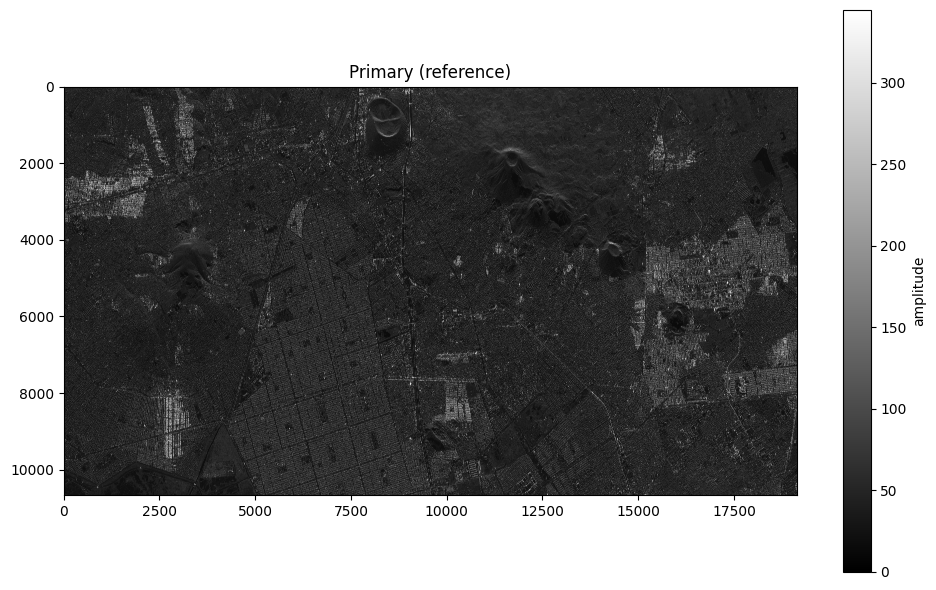

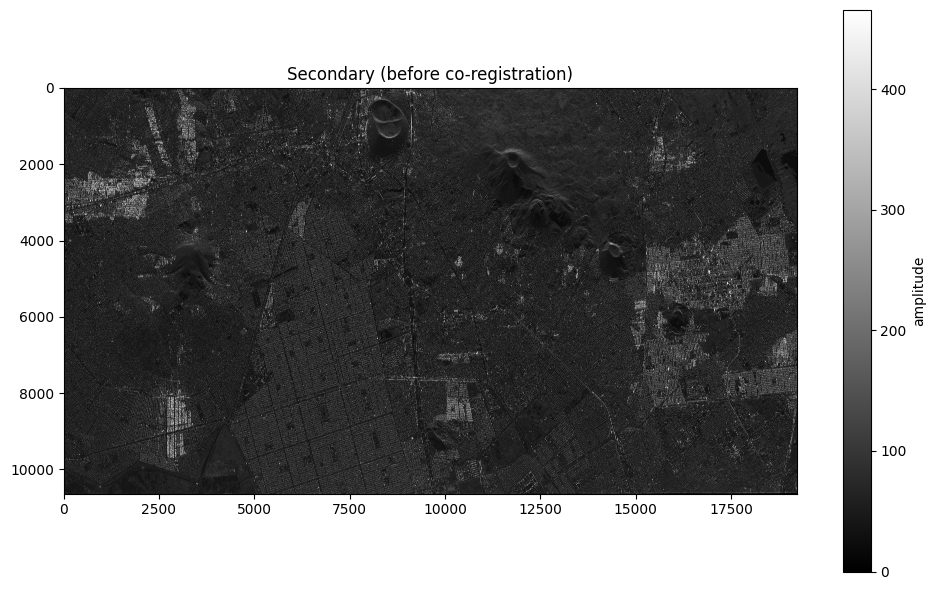

In [5]:
def quick_look(arr, title="", percentile=99):
    mag = np.abs(arr)
    vmax = np.percentile(mag, percentile)
    plt.figure(figsize=(10, 6))
    plt.imshow(mag, cmap="gray", vmin=0, vmax=vmax, origin="upper")
    plt.colorbar(label="amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()

quick_look(img_primary,   "Primary (reference)")
quick_look(img_secondary, "Secondary (before co-registration)")

## Cell 5 – Co-registration via phase cross-correlation

We work on amplitude images for the shift estimation, then apply the shift
to the *complex* secondary image so phase is preserved for coherence.


Co-registering secondary to primary ...
Estimated shift (row, col): [ 15.7 -70.4]  |  error: 1.0000
Done.


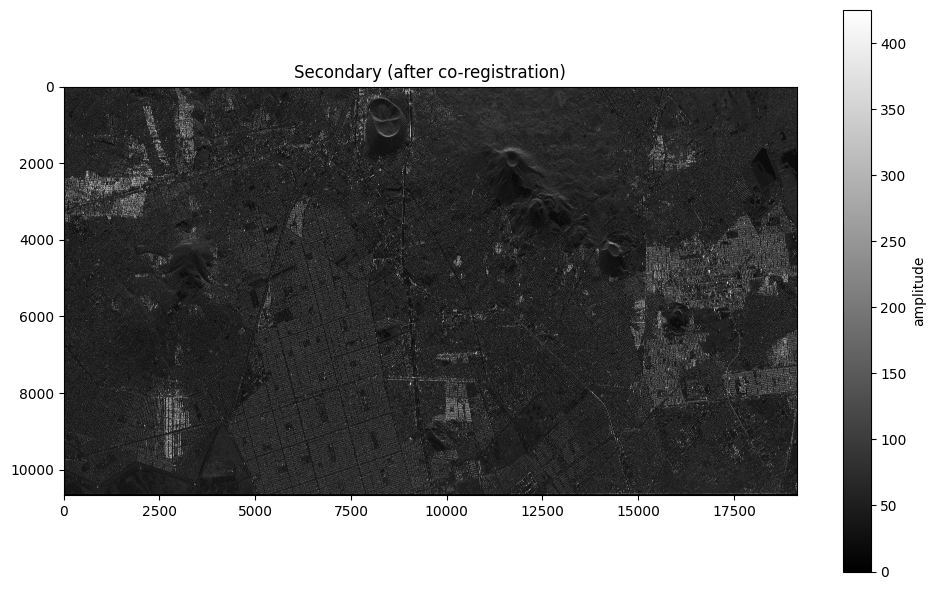

In [ ]:
def coregister(primary_cplx, secondary_cplx, upsample_factor=10):
    """
    Estimate integer+sub-pixel shift of secondary relative to primary
    using phase cross-correlation on log-magnitude images,
    then apply the shift to the complex secondary.
    Returns the shifted complex secondary (same shape as primary).
    """
    # Use log-magnitude for correlation (reduces speckle dynamic range)
    ref  = np.log1p(np.abs(primary_cplx))
    mov  = np.log1p(np.abs(secondary_cplx))

    # Crop/pad secondary magnitude to match primary shape for correlation
    rr = min(ref.shape[0], mov.shape[0])
    cc = min(ref.shape[1], mov.shape[1])
    ref_crop = ref[:rr, :cc]
    mov_crop = mov[:rr, :cc]

    shift, error, phase_diff = phase_cross_correlation(
        ref_crop, mov_crop, upsample_factor=upsample_factor
    )
    print(f"Estimated shift (row, col): {shift}  |  error: {error:.4f}")

    # Apply shift to complex secondary (real and imag parts separately)
    # nd_shift uses spline interpolation – fine for sub-pixel accuracy
    sec_real = nd_shift(secondary_cplx.real, shift)
    sec_imag = nd_shift(secondary_cplx.imag, shift)
    secondary_shifted = sec_real + 1j * sec_imag

    # Crop/pad to primary shape
    out = np.zeros_like(primary_cplx)
    rr2 = min(primary_cplx.shape[0], secondary_shifted.shape[0])
    cc2 = min(primary_cplx.shape[1], secondary_shifted.shape[1])
    out[:rr2, :cc2] = secondary_shifted[:rr2, :cc2]
    return out

print("Co-registering secondary to primary ...")
img_secondary_coreg = coregister(img_primary, img_secondary, upsample_factor=UPSAMPLE)
print("Done.")

quick_look(img_secondary_coreg, "Secondary (after co-registration)")

## Cell 6 – Coherence computation

The coherence magnitude between two SAR images s1, s2 over a window W is:

$$|\gamma| = \frac{|\sum_{W} s_1 \cdot s_2^*|}{\sqrt{\sum_W |s_1|^2 \cdot \sum_W |s_2|^2}}$$

Values near 1 = coherent (no change); values near 0 = incoherent (change).

In [7]:
from scipy.ndimage import uniform_filter

def coherence(s1, s2, win_rows=7, win_cols=7):
    """
    Compute magnitude of complex coherence with a rectangular averaging window.
    """
    size = (win_rows, win_cols)

    # Cross product
    cross      = s1 * np.conj(s2)

    # Averaged numerator (complex) and denominators (real)
    num_r  = uniform_filter(cross.real, size=size)
    num_i  = uniform_filter(cross.imag, size=size)
    num    = np.abs(num_r + 1j * num_i)

    den1   = uniform_filter(np.abs(s1)**2, size=size)
    den2   = uniform_filter(np.abs(s2)**2, size=size)
    den    = np.sqrt(den1 * den2)

    # Avoid divide-by-zero
    coh = np.where(den > 0, num / den, 0.0)
    return coh.astype(np.float32)


print(f"Computing coherence with window ({WIN_ROWS}x{WIN_COLS}) ...")
coh_map = coherence(img_primary, img_secondary_coreg, win_rows=WIN_ROWS, win_cols=WIN_COLS)
print(f"Coherence range: [{coh_map.min():.3f}, {coh_map.max():.3f}]")

Computing coherence with window (9x9) ...


C:\Users\poppy\AppData\Local\Temp\ipykernel_14032\4129585167.py:19: RuntimeWarning: invalid value encountered in sqrt
  den    = np.sqrt(den1 * den2)
C:\Users\poppy\AppData\Local\Temp\ipykernel_14032\4129585167.py:22: RuntimeWarning: invalid value encountered in divide
  coh = np.where(den > 0, num / den, 0.0)


Coherence range: [0.000, 0.997]


## Cell 7 – Visualise coherence

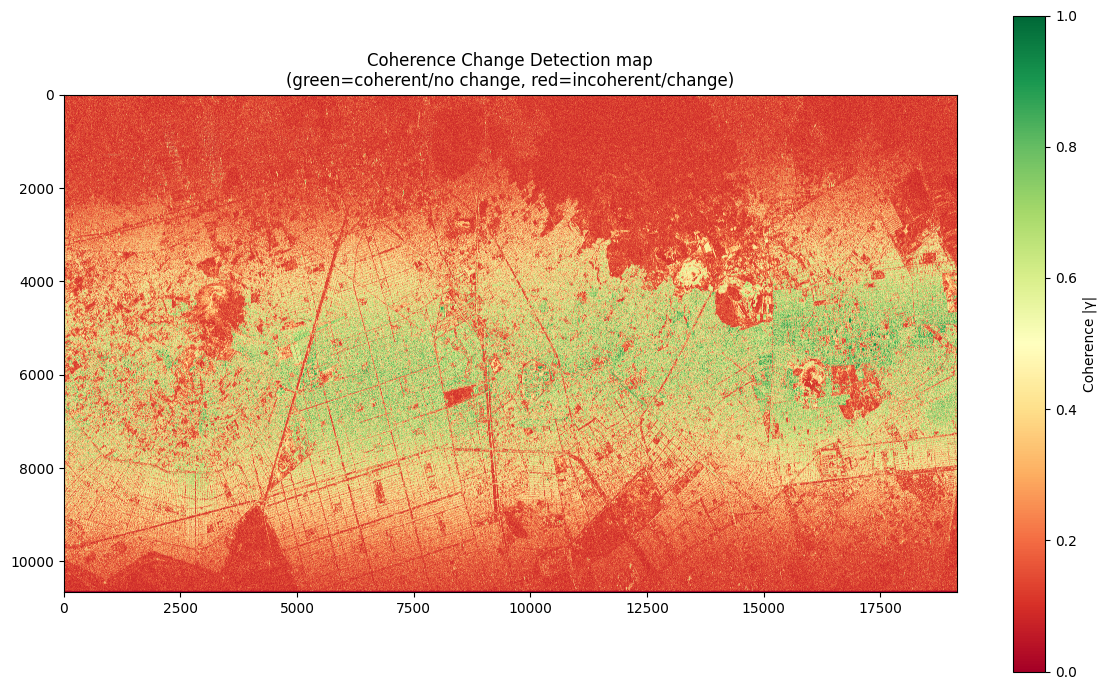

In [8]:
plt.figure(figsize=(12, 7))
plt.imshow(coh_map, cmap="RdYlGn", vmin=0, vmax=1, origin="upper")
plt.colorbar(label="Coherence |γ|")
plt.title("Coherence Change Detection map\n(green=coherent/no change, red=incoherent/change)")
plt.tight_layout()
plt.show()

## Cell 8 – Save as georeferenced GeoTIFF

In [9]:
def save_georeferenced_tiff(path, data_array, transform, crs, nodata=None):
    """
    Write a single-band float32 array as a compressed GeoTIFF, carrying
    the geospatial metadata (transform + CRS) from the primary SICD image.

    Parameters
    ----------
    path       : str or Path  – output file path
    data_array : np.ndarray   – 2-D float32 array (rows × cols)
    transform  : Affine       – rasterio affine transform (pixel → coords)
    crs        : CRS          – coordinate reference system
    nodata     : float|None   – nodata sentinel (default None)
    """
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    profile = {
        "driver":    "GTiff",
        "dtype":     rasterio.float32,
        "width":     data_array.shape[1],
        "height":    data_array.shape[0],
        "count":     1,
        "crs":       crs,
        "transform": transform,
        "compress":  "deflate",
        "predictor": 3,       # floating-point predictor for better compression
        "zlevel":    6,
    }
    if nodata is not None:
        profile["nodata"] = nodata

    with rasterio.open(path, "w", **profile) as dst:
        dst.write(data_array.astype(np.float32), 1)
    print(f"Saved georeferenced GeoTIFF → {Path(path).resolve()}")


save_georeferenced_tiff(
    path       = OUTPUT_TIF,
    data_array = coh_map,
    transform  = GEO_TRANSFORM,
    crs        = GEO_CRS,
)

# Verify the saved file carries the expected georeference
with rasterio.open(OUTPUT_TIF) as verify:
    print(f"\nVerification of saved file:")
    print(f"  CRS       : {verify.crs}")
    print(f"  Transform : {verify.transform}")
    print(f"  Bounds    : {verify.bounds}")
    print(f"  Shape     : {verify.height} x {verify.width}")
    print(f"  Dtype     : {verify.dtypes[0]}")


Saved georeferenced GeoTIFF → C:\Users\poppy\PythonStuff\Automation\Projects\NASASARCoherence\outputs\ccd_coherence.tif

Verification of saved file:
  CRS       : EPSG:4326
  Transform : |-0.00,-0.00,-98.90|
|-0.00, 0.00, 19.39|
| 0.00, 0.00, 1.00|
  Bounds    : BoundingBox(left=-99.1040235501081, bottom=19.25834305856234, right=-98.90273895815773, top=19.454120565939583)
  Shape     : 10661 x 19138
  Dtype     : float32


## (Optional) Cell 9 – Threshold map: flag changed pixels

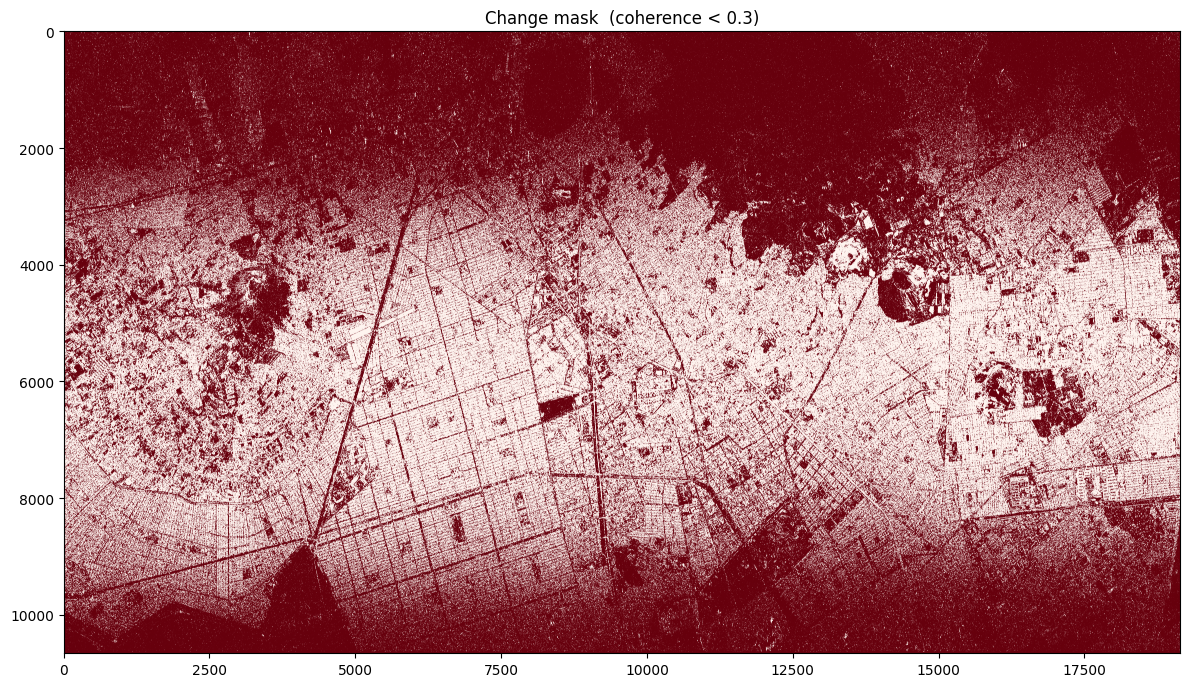

Saved georeferenced GeoTIFF → C:\Users\poppy\PythonStuff\Automation\Projects\NASASARCoherence\outputs\change_mask.tif


In [ ]:
COHERENCE_THRESHOLD = 0.3   # pixels below this are flagged as changed

change_mask = (coh_map < COHERENCE_THRESHOLD).astype(np.float32)

plt.figure(figsize=(12, 7))
plt.imshow(change_mask, cmap="Reds", origin="upper")
plt.title(f"Change mask  (coherence < {COHERENCE_THRESHOLD})")
plt.tight_layout()
plt.show()

CHANGE_MASK_TIF = Path(OUTPUT_TIF).parent / "change_mask.tif"
save_georeferenced_tiff(
    path       = CHANGE_MASK_TIF,
    data_array = change_mask,
    transform  = GEO_TRANSFORM,
    crs        = GEO_CRS,
)